In [ ]:
# ==========================================
# CELL 1: TẢI BẰNG KAGGLERHUB & GIẢI NÉN CHỌN LỌC
# ==========================================
import os
import zipfile
import shutil

# 1. Cài đặt và khai báo thư viện kagglehub chính thức
!pip install kagglehub -q
import kagglehub

# 2. Định nghĩa tên 5 class mục tiêu của đồ án
TARGET_CLASSES = ["Bowling", "BoxingPunchingBag", "Biking", "JumpRope", "PlayingGuitar"]
DATASET_DIR = "selected_dataset"
os.makedirs(DATASET_DIR, exist_ok=True)

print("⏳ Đang tải dataset UCF101 qua kagglehub (Tự động tối ưu tốc độ)...")
# Đường dẫn chính xác từ ảnh của bạn
downloaded_cache_path = kagglehub.dataset_download("pevogam/ucf101")
print(f"✅ Đã tải xong! Dữ liệu gốc nằm tại cache: {downloaded_cache_path}")

# 3. Bản chất xử lý: Quét tìm file zip hoặc thư mục chứa class để trích xuất cục bộ
print("📦 Đang tiến hành lọc và trích xuất thông minh 5 classes...")

# Tìm kiếm file zip gốc bên trong đường dẫn cache vừa tải về
zip_file_target = None
for root, dirs, files in os.walk(downloaded_cache_path):
    for file in files:
        if file.endswith('.zip'):
            zip_file_target = os.path.join(root, file)
            break

if zip_file_target and os.path.exists(zip_file_target):
    # Kịch bản 1: Nếu dữ liệu tải về là một file ZIP nén cục bộ
    print(f"🔍 Phát hiện file nén: {zip_file_target}. Tiến hành giải nén chọn lọc...")
    with zipfile.ZipFile(zip_file_target, 'r') as zip_ref:
        all_files = zip_ref.namelist()
        for class_name in TARGET_CLASSES:
            class_files = [f for f in all_files if f"/{class_name}/" in f or f"{class_name}/" in f.split('/')]
            if len(class_files) == 0:
                continue
            print(f" -> Đang giải nén {len(class_files)} files cho lớp: [ {class_name} ]")
            for file in class_files:
                zip_ref.extract(file, DATASET_DIR)
else:
    # Kịch bản 2: Nếu kagglehub đã tự động xả nén thư mục thô ra cache cho bạn
    print("🔍 Phát hiện thư mục thô. Tiến hành copy chọn lọc các class...")
    for root, dirs, files in os.walk(downloaded_cache_path):
        for class_name in TARGET_CLASSES:
            if class_name in dirs:
                source_class_dir = os.path.join(root, class_name)
                dest_class_dir = os.path.join(DATASET_DIR, class_name)
                if not os.path.exists(dest_class_dir):
                    print(f" -> Đang copy dữ liệu cho lớp: [ {class_name} ]")
                    shutil.copytree(source_class_dir, dest_class_dir)

print("\n🎉 Quá trình chuẩn bị thư mục đích hoàn tất thành công!")

# 4. Giải phóng hoàn toàn bộ nhớ đệm của Colab để tránh tràn ổ đĩa
try:
    shutil.rmtree(downloaded_cache_path)
    print("🗑️ Đã xóa cache thừa từ bộ nhớ đệm Kagglehub. Ổ đĩa sạch sẽ!")
except Exception as e:
    print("ℹ️ Lưu ý: Không cần xóa cache thủ công.")

# ==========================================
# CELL 2: PHÂN TÍCH VÀ TRÍCH XUẤT FRAME (Cập nhật kích thước & Chuẩn hóa)
# ==========================================
import cv2
import numpy as np

# Cấu hình tối ưu cho CNN truyền thống tự xây dựng (Tránh nổ tham số)
IMAGE_HEIGHT, IMAGE_WIDTH = 128, 128
SEQUENCE_LENGTH = 30

def extract_frames_from_video(video_path):
    """
    Trích xuất phân phối đều các khung hình từ video và chuẩn hóa pixel về [0, 1].
    """
    frames_list = []
    video_reader = cv2.VideoCapture(video_path)
    video_frames_count = int(video_reader.get(cv2.CAP_PROP_FRAME_COUNT))

    if video_frames_count < SEQUENCE_LENGTH:
        sampled_indices = np.arange(video_frames_count)
    else:
        sampled_indices = np.linspace(0, video_frames_count - 1, num=SEQUENCE_LENGTH).astype(int)

    for frame_index in sampled_indices:
        video_reader.set(cv2.CAP_PROP_POS_FRAMES, frame_index)
        success, frame = video_reader.read()

        if not success:
            break

        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        resized_frame = cv2.resize(frame_rgb, (IMAGE_HEIGHT, IMAGE_WIDTH))

        # Chuẩn hóa Min-Max [0, 1] phù hợp cho mạng CNN huấn luyện từ đầu (Scratch)
        normalized_frame = resized_frame.astype(np.float32) / 255.0
        frames_list.append(normalized_frame)

    video_reader.release()

    # Padding bằng khung hình rỗng nếu video quá ngắn
    while len(frames_list) < SEQUENCE_LENGTH:
        frames_list.append(np.zeros((IMAGE_HEIGHT, IMAGE_WIDTH, 3), dtype=np.float32))

    return np.array(frames_list, dtype=np.float32)

# =====================================================================
# CELL 3: XÂY DỰNG KIẾN TRÚC MÔ HÌNH END-TO-END (CNN THUẦN + LSTM)
# =====================================================================
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense, LSTM, TimeDistributed

def create_traditional_cnn_lstm_model():
    """
    Xây dựng mô hình End-to-End LRCN sử dụng CNN truyền thống và LSTM.
    Ràng buộc: Không sử dụng Transfer Learning, không sử dụng Residual Connections.
    """
    model = Sequential(name="Traditional_CNN_LSTM_Network")

    # --- CẤU TRÚC KHỐI CNN TRUYỀN THỐNG (Được phân phối theo thời gian) ---
    # Tầng CNN số 1: Trích xuất các đặc trưng hình học cơ bản
    model.add(TimeDistributed(Conv2D(16, (3, 3), padding='same', activation='relu'),
                              input_shape=(SEQUENCE_LENGTH, IMAGE_HEIGHT, IMAGE_WIDTH, 3)))
    model.add(TimeDistributed(MaxPooling2D((2, 2))))
    model.add(TimeDistributed(Dropout(0.25)))

    # Tầng CNN số 2: Tăng độ sâu bộ lọc để học đặc trưng phức tạp hơn
    model.add(TimeDistributed(Conv2D(32, (3, 3), padding='same', activation='relu')))
    model.add(TimeDistributed(MaxPooling2D((2, 2))))
    model.add(TimeDistributed(Dropout(0.25)))

    # Tầng CNN số 3
    model.add(TimeDistributed(Conv2D(64, (3, 3), padding='same', activation='relu')))
    model.add(TimeDistributed(MaxPooling2D((2, 2))))
    model.add(TimeDistributed(Dropout(0.25)))

    # Tầng phẳng hóa (Flatten) để chuyển bản đồ đặc trưng 2D thành vector 1D phẳng
    model.add(TimeDistributed(Flatten()))

    # --- CẤU TRÚC KHỐI CHUỖI THỜI GIAN (LSTM) ---
    # LSTM nhận đầu vào là chuỗi đặc trưng dạng: (Khung hình, Kích thước vector phẳng)
    model.add(LSTM(64, return_sequences=False))
    model.add(Dropout(0.5))

    # Tầng Phân loại đầu ra (Cơ chế Softmax cho bài toán phân loại đa lớp)
    # 5 nút tương ứng với 5 lớp hành động mục tiêu
    model.add(Dense(5, activation='softmax'))

    return model

# Khởi tạo mô hình
video_classifier = create_traditional_cnn_lstm_model()
video_classifier.summary()

# Thiết lập hàm tối ưu và hàm tổn thất tiêu chuẩn quốc tế
video_classifier.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
print("✅ Khởi tạo thành công mô hình CNN-LSTM thuần tuý và cấu hình bộ tối ưu!")
# =====================================================================
# CELL 4: Thu thập đường dẫn file
# =====================================================================
import os
import numpy as np

def collect_video_paths_and_labels():
    """
    Chỉ thu thập đường dẫn tệp video và nhãn số nguyên tương ứng, KHÔNG nạp ảnh vào RAM.
    """
    video_paths = []
    video_labels = []

    for class_index, class_name in enumerate(TARGET_CLASSES):
        class_dir = None
        for root, dirs, _ in os.walk(DATASET_DIR):
            if class_name in dirs:
                class_dir = os.path.join(root, class_name)
                break

        if class_dir is None:
            continue

        video_files = [f for f in os.listdir(class_dir) if f.endswith(('.avi', '.mp4'))]
        print(f"📁 Đã ghi nhận: Lớp {class_name} -> {len(video_files)} video đường dẫn.")

        for video_name in video_files:
            video_path = os.path.join(class_dir, video_name)
            video_paths.append(video_path)
            video_labels.append(class_index)

    return np.array(video_paths), np.array(video_labels)

# Tiến hành quét danh mục
all_paths, all_labels = collect_video_paths_and_labels()
print(f"\n✅ Tổng số đường dẫn video đã ghi nhận: {len(all_paths)} (RAM tiêu thụ cực thấp!)")

⏳ Đang tải dataset UCF101 qua kagglehub (Tự động tối ưu tốc độ)...
Using Colab cache for faster access to the 'ucf101' dataset.
✅ Đã tải xong! Dữ liệu gốc nằm tại cache: /kaggle/input/ucf101
📦 Đang tiến hành lọc và trích xuất thông minh 5 classes...
🔍 Phát hiện thư mục thô. Tiến hành copy chọn lọc các class...
 -> Đang copy dữ liệu cho lớp: [ Bowling ]
 -> Đang copy dữ liệu cho lớp: [ BoxingPunchingBag ]
 -> Đang copy dữ liệu cho lớp: [ Biking ]
 -> Đang copy dữ liệu cho lớp: [ JumpRope ]
 -> Đang copy dữ liệu cho lớp: [ PlayingGuitar ]

🎉 Quá trình chuẩn bị thư mục đích hoàn tất thành công!
ℹ️ Lưu ý: Không cần xóa cache thủ công.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "Traditional_CNN_LSTM_Network"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed                │ (None, 30, 128, 128,   │           448 │
│ (TimeDistributed)               │ 16)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 30, 64, 64, 16) │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_2              │ (None, 30, 64, 64, 16) │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_3              │ (None, 30, 64, 64, 32) │         4,640 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_4              │ (None, 30, 32, 32, 32) │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_5              │ (None, 30, 32, 32, 32) │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_6              │ (None, 30, 32, 32, 64) │        18,496 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_7              │ (None, 30, 16, 16, 64) │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_8              │ (None, 30, 16, 16, 64) │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_9              │ (None, 30, 16384)      │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │     4,210,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,234,853 (16.15 MB)

 Trainable params: 4,234,853 (16.15 MB)

 Non-trainable params: 0 (0.00 B)

✅ Khởi tạo thành công mô hình CNN-LSTM thuần tuý và cấu hình bộ tối ưu!
📁 Đã ghi nhận: Lớp Bowling -> 155 video đường dẫn.
📁 Đã ghi nhận: Lớp BoxingPunchingBag -> 163 video đường dẫn.
📁 Đã ghi nhận: Lớp Biking -> 134 video đường dẫn.
📁 Đã ghi nhận: Lớp JumpRope -> 144 video đường dẫn.
📁 Đã ghi nhận: Lớp PlayingGuitar -> 160 video đường dẫn.

✅ Tổng số đường dẫn video đã ghi nhận: 756 (RAM tiêu thụ cực thấp!)


In [ ]:
# =====================================================================
# CELL 5: Phân chia tập dữ liệu 70/15/15 trên danh sách đường dẫn
# =====================================================================
from sklearn.model_selection import train_test_split
from google.colab import drive

# 1. Mount Google Drive để lưu trọng số
print("👉 Vui lòng xác thực để kết nối Google Drive:")
drive.mount('/content/drive')
DRIVE_MODEL_DIR = "/content/drive/MyDrive/DoAn_DeepLearning_UCF5/Models"
os.makedirs(DRIVE_MODEL_DIR, exist_ok=True)

# 2. Phân chia tỷ lệ chuẩn khoa học 70/15/15 dựa trên đường dẫn
paths_train_val, paths_test, labels_train_val, labels_test = train_test_split(
    all_paths, all_labels, test_size=0.15, shuffle=True, random_state=42, stratify=all_labels
)

paths_train, paths_val, labels_train, labels_val = train_test_split(
    paths_train_val, labels_train_val, test_size=0.1764, shuffle=True, random_state=42, stratify=labels_train_val
)

print("\n🎉 PHÂN CHIA ĐƯỜNG DẪN THÀNH CÔNG!")
print(f"📊 Số lượng video Tập Train : {len(paths_train)}")
print(f"📊 Số lượng video Tập Val   : {len(paths_val)}")
print(f"📊 Số lượng video Tập Test  : {len(paths_test)}")

👉 Vui lòng xác thực để kết nối Google Drive:
Mounted at /content/drive

🎉 PHÂN CHIA ĐƯỜNG DẪN THÀNH CÔNG!
📊 Số lượng video Tập Train : 528
📊 Số lượng video Tập Val   : 114
📊 Số lượng video Tập Test  : 114


In [ ]:
# =====================================================================
# Cell 5: Xây dựng Bộ Sinh Dữ Liệu Tối Ưu Hóa RAM (Data Generator)
# =====================================================================
import tensorflow as tf

class VideoDataGenerator(tf.keras.utils.Sequence):
    """
    Bộ sinh dữ liệu cuốn chiếu: Chỉ đọc và xử lý video theo từng Batch được yêu cầu.
    """
    def __init__(self, video_paths, labels, batch_size=8, sequence_length=30,
                 image_height=128, image_width=128, shuffle=True):
        self.video_paths = video_paths
        self.labels = labels
        self.batch_size = batch_size
        self.sequence_length = sequence_length
        self.image_height = image_height
        self.image_width = image_width
        self.shuffle = shuffle
        self.indexes = np.arange(len(self.video_paths))
        if self.shuffle:
            np.random.shuffle(self.indexes)

    def __len__(self):
        # Trả về số lượng batch trong một epoch
        return int(np.ceil(len(self.video_paths) / self.batch_size))

    def __getitem__(self, index):
        # Lấy chỉ mục của batch hiện tại
        batch_indexes = self.indexes[index * self.batch_size : (index + 1) * self.batch_size]

        batch_paths = self.video_paths[batch_indexes]
        batch_labels = self.labels[batch_indexes]

        X, y = self.__data_generation(batch_paths, batch_labels)
        return X, y

    def on_epoch_end(self):
        # Trộn đều dữ liệu sau mỗi epoch để tăng tính tổng quát hóa
        if self.shuffle:
            np.random.shuffle(self.indexes)

    def __data_generation(self, batch_paths, batch_labels):
        X_batch = []
        Y_batch = []

        for path, label in zip(batch_paths, batch_labels):
            # Gọi lại hàm trích xuất và chuẩn hóa khung hình ở CELL 2 của bạn
            frames = extract_frames_from_video(path)
            X_batch.append(frames)
            Y_batch.append(label)

        return np.array(X_batch, dtype=np.float32), np.array(Y_batch, dtype=np.int8)

# Khởi tạo các bộ sinh dữ liệu (Generator) cho 3 tập độc lập
# Đặt batch_size = 8 hoặc 16 tùy dung lượng GPU của bạn (An toàn nhất là kích thước 8)
BATCH_SIZE = 8

train_generator = VideoDataGenerator(paths_train, labels_train, batch_size=BATCH_SIZE, shuffle=True)
val_generator = VideoDataGenerator(paths_val, labels_val, batch_size=BATCH_SIZE, shuffle=False)
test_generator = VideoDataGenerator(paths_test, labels_test, batch_size=BATCH_SIZE, shuffle=False)

print("⚙️ Bộ sinh dữ liệu an toàn RAM đã sẵn sàng kết nối với hàm mô hình .fit()!")

⚙️ Bộ sinh dữ liệu an toàn RAM đã sẵn sàng kết nối với hàm mô hình .fit()!


In [ ]:
# =====================================================================
# CELL 5.5: LƯU CẤU TRÚC PHÂN CHIA (Chạy ngay trước khi tắt máy)
# =====================================================================
import pandas as pd
import os

train_df = pd.DataFrame({'video_path': paths_train, 'label': labels_train})
val_df = pd.DataFrame({'video_path': paths_val, 'label': labels_val})
test_df = pd.DataFrame({'video_path': paths_test, 'label': labels_test})

train_df.to_csv(os.path.join(DRIVE_MODEL_DIR, 'train_split.csv'), index=False)
val_df.to_csv(os.path.join(DRIVE_MODEL_DIR, 'val_split.csv'), index=False)
test_df.to_csv(os.path.join(DRIVE_MODEL_DIR, 'test_split.csv'), index=False)

print("💾 Đã đồng bộ an toàn cả 3 file CSV phân chia dữ liệu lên Google Drive!")

In [ ]:
# =====================================================================
# CELL 5.ALT: TẢI DANH SÁCH ĐƯỜNG DẪN TỪ DRIVE (Chỉ chạy khi khởi động lại Colab)
# =====================================================================
import os
import pandas as pd
import numpy as np
from google.colab import drive
import tensorflow as tf

# 1. Mount Drive lại để đọc file
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

DRIVE_MODEL_DIR = "/content/drive/MyDrive/DoAn_DeepLearning_UCF5/Models"

# 2. Đọc ngược danh sách file từ các tệp CSV đã lưu
def load_split_from_csv(filename):
    file_path = os.path.join(DRIVE_MODEL_DIR, filename)
    df = pd.read_csv(file_path)
    return df['video_path'].values, df['label'].values

paths_train, labels_train = load_split_from_csv('train_split.csv')
paths_val, labels_val = load_split_from_csv('val_split.csv')
paths_test, labels_test = load_split_from_csv('test_split.csv')

print("✅ Đã khôi phục thành công danh sách dữ liệu từ Google Drive!")
print(f"📊 Tập Train: {len(paths_train)} | Tập Val: {len(paths_val)} | Tập Test: {len(paths_test)}")

# 3. Tái khởi tạo lại các Bộ sinh dữ liệu (Generator) là xong!
BATCH_SIZE = 8
train_generator = VideoDataGenerator(paths_train, labels_train, batch_size=BATCH_SIZE, shuffle=True)
val_generator = VideoDataGenerator(paths_val, labels_val, batch_size=BATCH_SIZE, shuffle=False)
test_generator = VideoDataGenerator(paths_test, labels_test, batch_size=BATCH_SIZE, shuffle=False)

print("⚙️ Các đường ống Generator đã được tái cấu trúc thành công, sẵn sàng cho việc Train/Test!")

In [ ]:
# =====================================================================
# CELL 6: HUẤN LUYỆN MÔ HÌNH VỚI GENERATOR VÀ TỰ ĐỘNG LƯU LÊN DRIVE
# =====================================================================
import os
import tensorflow as tf
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# 1. Định nghĩa đường dẫn file lưu trọng số trên Google Drive
# Chúng ta dùng định dạng đuôi '.keras' theo chuẩn mới nhất của Keras 3 / TensorFlow 2.x
MODEL_SAVE_PATH = os.path.join(DRIVE_MODEL_DIR, 'best_cnn_lstm_model.keras')

# 2. Cấu hình Callback ModelCheckpoint - "Người gác đền" tự động lưu file lên Drive
checkpoint_callback = ModelCheckpoint(
    filepath=MODEL_SAVE_PATH,        # Đường dẫn lưu file trên Drive của bạn
    monitor='val_loss',              # Giám sát giá trị Loss trên tập Kiểm định (Validation)
    save_best_only=True,             # CHỈ lưu lại phiên bản có val_loss thấp nhất (tốt nhất)
    mode='min',                      # Tìm giá trị nhỏ nhất cho loss
    verbose=1                        # Hiển thị thông báo mỗi khi lưu file thành công
)

# 3. Cấu hình EarlyStopping - Tự động dừng cuộc chơi nếu mô hình bị bão hòa (Chống Overfitting)
early_stopping_callback = EarlyStopping(
    monitor='val_loss',
    patience=5,                      # Nếu sau 5 epoch liên tiếp mà val_loss không giảm thêm, dừng huấn luyện
    restore_best_weights=True        # Khôi phục lại trọng số tốt nhất sau khi dừng
)

# 4. Kích hoạt tiến trình huấn luyện cuốn chiếu kết nối trực tiếp GPU
print("⏳ Kích hoạt tiến trình huấn luyện mạng End-to-End CNN-LSTM thuần...")
print(f"📁 Mô hình tốt nhất sẽ được tự động ghi đè liên tục vào: {MODEL_SAVE_PATH}\n")

history = video_classifier.fit(
    train_generator,                 # Bộ sinh dữ liệu tập Train (70%)
    validation_data=val_generator,   # Bộ sinh dữ liệu tập Validation (15%)
    epochs=20,                       # Số vòng lặp (có thể tăng lên 30-50 tùy thời gian Colab cho phép)
    callbacks=[checkpoint_callback, early_stopping_callback], # Nhúng các bộ giám sát vào luồng chạy
    verbose=1
)

print("\n🎉 Chúc mừng! Tiến trình huấn luyện đã hoàn tất xuất sắc.")

⏳ Kích hoạt tiến trình huấn luyện mạng End-to-End CNN-LSTM thuần...
📁 Mô hình tốt nhất sẽ được tự động ghi đè liên tục vào: /content/drive/MyDrive/DoAn_DeepLearning_UCF5/Models/best_cnn_lstm_model.keras

Epoch 1/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.3886 - loss: 1.4611
Epoch 1: val_loss improved from None to 1.40367, saving model to /content/drive/MyDrive/DoAn_DeepLearning_UCF5/Models/best_cnn_lstm_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/DoAn_DeepLearning_UCF5/Models/best_cnn_lstm_model.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 176s 3s/step - accuracy: 0.3939 - loss: 1.4283 - val_accuracy: 0.4737 - val_loss: 1.4037
Epoch 2/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4214 - loss: 1.3607
Epoch 2: val_loss improved from 1.40367 to 1.32207, saving model to /content/drive/MyDrive/DoAn_DeepLearning_UCF5/Models/best_cnn_lstm_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/DoAn_DeepLearning_UCF5/Models/best_cnn_lstm_model.k

In [ ]:
# =====================================================================
# CELL 6.ALT: LƯU LỊCH SỬ HUẤN LUYỆN (HISTORY) LÊN DRIVE
# (Chạy ngay sau khi CELL 6 vừa hoàn thành)
# =====================================================================
import json
import os

# 1. Định nghĩa đường dẫn file lưu lịch sử
HISTORY_SAVE_PATH = os.path.join(DRIVE_MODEL_DIR, 'training_history.json')

# 2. Trích xuất từ điển chứa đầy đủ thông số: loss, accuracy, val_loss, val_accuracy
history_dict = history.history

# 3. Ghi dữ liệu vào file JSON trên Drive
with open(HISTORY_SAVE_PATH, 'w') as f:
    json.dump(history_dict, f)

print(f"💾 Đã lưu toàn bộ thông số huấn luyện thành công tại: {HISTORY_SAVE_PATH}")
print("👉 Giờ đây bạn có thể an tâm tắt Colab và đi giải quyết việc bận rồi!")

💾 Đã lưu toàn bộ thông số huấn luyện thành công tại: /content/drive/MyDrive/DoAn_DeepLearning_UCF5/Models/training_history.json
👉 Giờ đây bạn có thể an tâm tắt Colab và đi giải quyết việc bận rồi!


In [ ]:
# =====================================================================
# CELL LOAD_RECOVERY: KHÔI PHỤC MÔ HÌNH VÀ THÔNG SỐ (Chạy khi bạn quay lại)
# =====================================================================
import os
import json
import tensorflow as tf
from google.colab import drive

# 1. Kết nối lại Drive
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

DRIVE_MODEL_DIR = "/content/drive/MyDrive/DoAn_DeepLearning_UCF5/Models"
MODEL_SAVE_PATH = os.path.join(DRIVE_MODEL_DIR, 'best_cnn_lstm_model.keras')
HISTORY_SAVE_PATH = os.path.join(DRIVE_MODEL_DIR, 'training_history.json')

# 2. Tải lại "bộ não" mô hình tối ưu nhất
print("⏳ Đang nạp mô hình CNN-LSTM từ Drive...")
loaded_model = tf.keras.models.load_model(MODEL_SAVE_PATH)
print("✅ Đã nạp mô hình thành công!")

# 3. Tải lại toàn bộ thông số Accuracy, Loss, Val_loss, Val_Accuracy
print("⏳ Đang trích xuất lại lịch sử thông số huấn luyện...")
with open(HISTORY_SAVE_PATH, 'r') as f:
    saved_history = json.load(f)
print("✅ Đã phục hồi đầy đủ thông số khóa học!")

⏳ Đang nạp mô hình CNN-LSTM từ Drive...
✅ Đã nạp mô hình thành công!
⏳ Đang trích xuất lại lịch sử thông số huấn luyện...
✅ Đã phục hồi đầy đủ thông số khóa học!


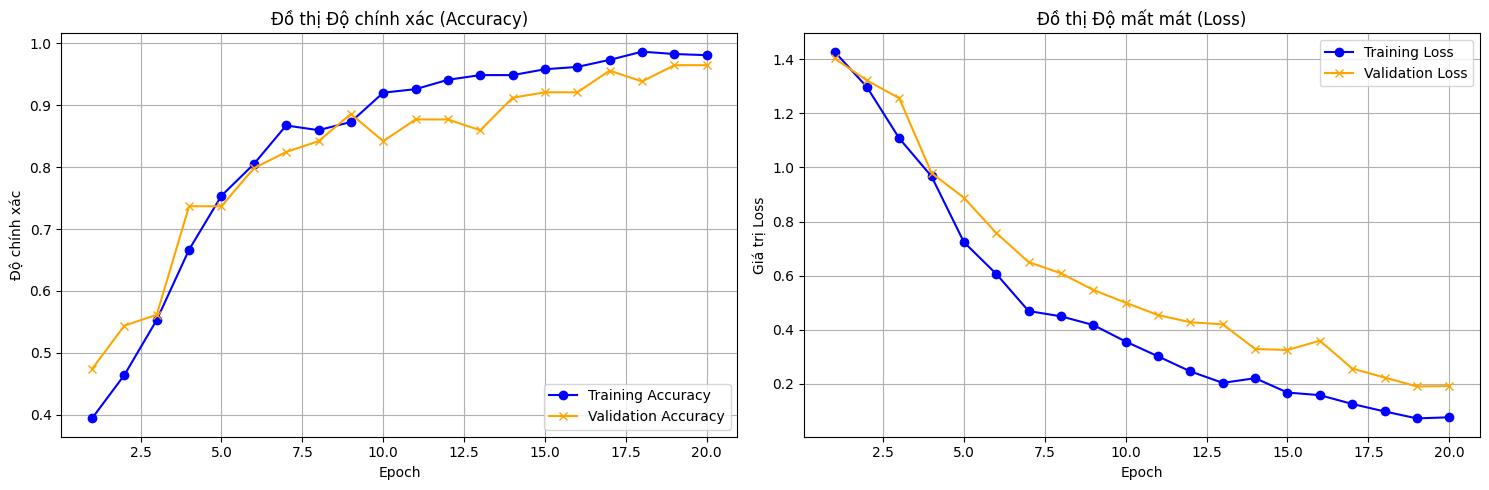

In [ ]:
# =====================================================================
# CELL 7 (CẬP NHẬT): VẼ BIỂU ĐỒ TỪ FILE LOAD ĐÃ LƯU
# =====================================================================
import matplotlib.pyplot as plt

acc = saved_history['accuracy']
val_acc = saved_history['val_accuracy']
loss = saved_history['loss']
val_loss = saved_history['val_loss']
epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(15, 5))

# Đồ thị Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', color='blue', marker='o')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='orange', marker='x')
plt.title('Đồ thị Độ chính xác (Accuracy)')
plt.xlabel('Epoch')
plt.ylabel('Độ chính xác')
plt.legend(loc='lower right')
plt.grid(True)

# Đồ thị Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', color='blue', marker='o')
plt.plot(epochs_range, val_loss, label='Validation Loss', color='orange', marker='x')
plt.title('Đồ thị Độ mất mát (Loss)')
plt.xlabel('Epoch')
plt.ylabel('Giá trị Loss')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# =====================================================================
# CELL 8: ĐÁNH GIÁ KHÁCH QUAN MÔ HÌNH SAU KHI KHÔI PHỤC TRẠNG THÁI
# =====================================================================
print("⏳ Đang tiến hành kiểm tra mô hình trên tập Test độc lập từ Drive...")

# Sử dụng mô hình đã load và bộ tạo dữ liệu test đã khôi phục từ file CSV
test_loss, test_accuracy = loaded_model.evaluate(test_generator, verbose=1)

print("\n📊 --- KẾT QUẢ ĐÁNH GIÁ SAU KHI KHÔI PHỤC TRẠNG THÁI ---")
print(f"🎯 Độ chính xác thực tế trên tập Test (Test Accuracy) : {test_accuracy * 100:.2f}%")
print(f"📉 Sai số thực tế trên tập Test (Test Loss)          : {test_loss:.4f}")

⏳ Đang tiến hành kiểm tra mô hình trên tập Test độc lập từ Drive...
15/15 ━━━━━━━━━━━━━━━━━━━━ 34s 2s/step - accuracy: 0.9474 - loss: 0.2087

📊 --- KẾT QUẢ ĐÁNH GIÁ SAU KHI KHÔI PHỤC TRẠNG THÁI ---
🎯 Độ chính xác thực tế trên tập Test (Test Accuracy) : 94.74%
📉 Sai số thực tế trên tập Test (Test Loss)          : 0.2087
